In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.constants import Boltzmann

In [4]:
#Create a lattice 
#Create a vacancy
#Render the lattice
#Using random walk make the vacancy move
#Now the vacancy can move anywhere 
#Introduce Kinetic Monte Carlo

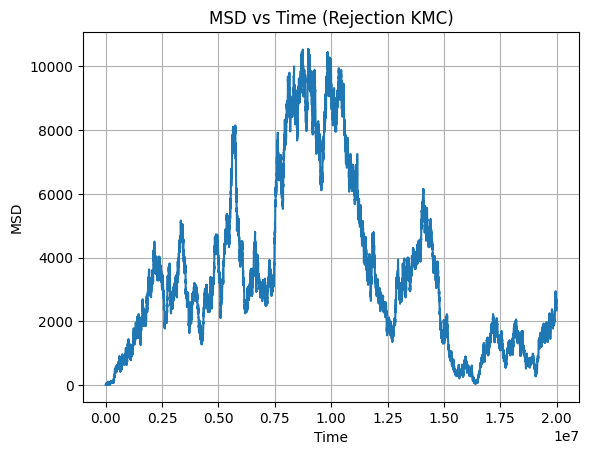

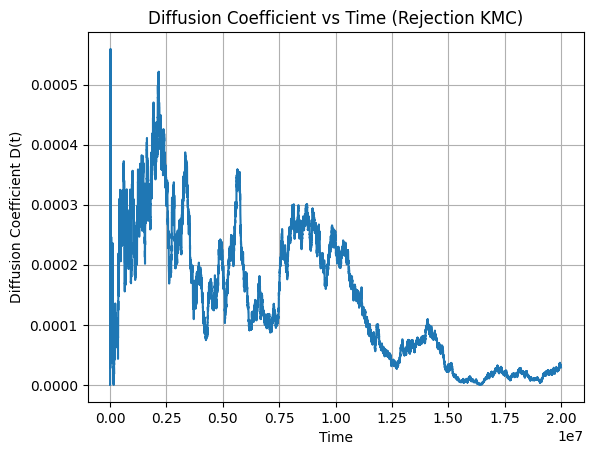

Rejection KMC Diffusion Coefficient: -5.285441669867434e-05


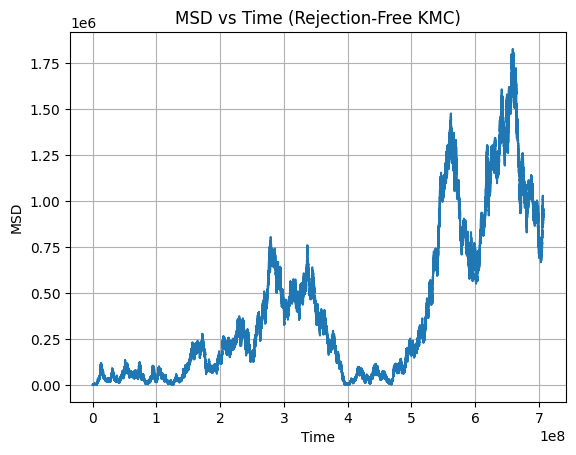

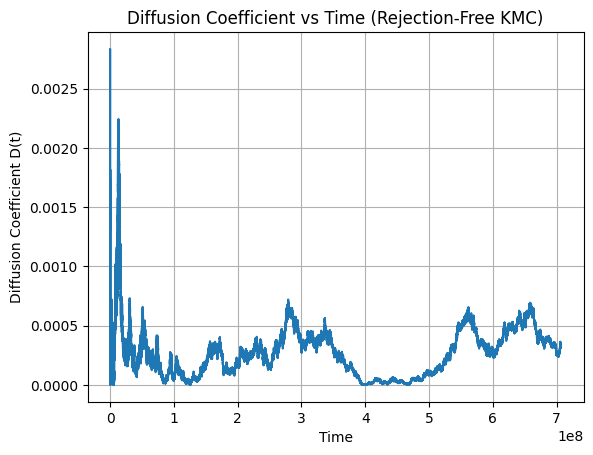

Rejection-Free KMC Diffusion Coefficient: 0.00042202571019605943


In [3]:
import numpy as np
import matplotlib.pyplot as plt


class Lattice:
    def __init__(self,length=10,numVac=1,seed=42):
        
        np.random.seed(seed)

        self.length = length
        self.numVac = numVac
        
        self.grid = np.ones((length,length), dtype=int)

        self.vacancy = []

        choices = np.random.choice(length*length,numVac,replace=False)

        for idx in choices:
            x = idx // length
            y = idx % length

            self.grid[x,y] = 0 
            self.vacancy.append([x,y])

    
    def printLattice(self):
        atoms = np.argwhere(self.grid == 1)
        vacancies = np.argwhere(self.grid == 0)
        
        if len(atoms) > 0:
            plt.scatter(atoms[:,0],atoms[:,1],c="blue",label="Atoms")
        if len(vacancies) > 0:
            plt.scatter(vacancies[:,0],vacancies[:,1],c="red",label="Vacancy")
        
        plt.legend()
        plt.title("Lattice")
        plt.show()


    def rejectionKMC(self, activationEnergy, Temperature=273, iterations=1000):

        kB = 8.617e-5   # eV/K
        length = self.length
        directions = [[1,0],[-1,0],[0,1],[0,-1]]

        jumpProb = np.exp(-activationEnergy / (kB * Temperature))

        vacancy_positions = []
        unwrapped_positions = []
        times = []

        x0, y0 = self.vacancy[0]

        unwrap_x, unwrap_y = x0, y0

        time = 0

        vacancy_positions.append((x0,y0))
        unwrapped_positions.append((unwrap_x, unwrap_y))
        times.append(time)

        for _ in range(iterations):

            for i, (x, y) in enumerate(self.vacancy):

                idx = np.random.choice(len(directions))
                dx, dy = directions[idx]

                newX = (x + dx) % length
                newY = (y + dy) % length

                if np.random.rand() < jumpProb:

                    self.grid[x, y] = 1
                    self.grid[newX, newY] = 0
                    self.vacancy[i] = [newX, newY]

                    unwrap_x += dx
                    unwrap_y += dy

            time += 1

            vacancy_positions.append(tuple(self.vacancy[0]))
            unwrapped_positions.append((unwrap_x, unwrap_y))
            times.append(time)

        positions = np.array(unwrapped_positions)
        times = np.array(times)

        dx = positions[:,0] - x0
        dy = positions[:,1] - y0

        msd = dx**2 + dy**2

        # MSD plot
        plt.figure()
        plt.plot(times, msd)
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.title("MSD vs Time (Rejection KMC)")
        plt.grid()
        plt.show()

        # Diffusion coefficient vs time
        valid = times > 0
        D_t = msd[valid] / (4.0 * times[valid])

        plt.figure()
        plt.plot(times[valid], D_t)
        plt.xlabel("Time")
        plt.ylabel("Diffusion Coefficient D(t)")
        plt.title("Diffusion Coefficient vs Time (Rejection KMC)")
        plt.grid()
        plt.show()

        start = len(times)//10
        coeffs = np.polyfit(times[start:], msd[start:], 1)

        slope = coeffs[0]

        self.DiffusionCoeff = slope / 4.0

        return self.DiffusionCoeff



    def rejectionFreeKMC(self, activationEnergy, Temperature=273, iterations=1000):

        kB = 8.617e-5
        length = self.length
        directions = [[1,0],[-1,0],[0,1],[0,-1]]

        rate = np.exp(-activationEnergy/(kB*Temperature))

        vacancy_positions = []
        unwrapped_positions = []
        times = []

        x0, y0 = self.vacancy[0]

        unwrap_x, unwrap_y = x0, y0

        time = 0.0

        vacancy_positions.append((x0,y0))
        unwrapped_positions.append((unwrap_x, unwrap_y))
        times.append(time)

        for step in range(iterations):

            x, y = self.vacancy[0]

            totalRate = 4 * rate

            idx = np.random.choice(4)
            dx, dy = directions[idx]

            newX = (x + dx) % length
            newY = (y + dy) % length

            self.grid[x,y] = 1
            self.grid[newX,newY] = 0
            self.vacancy[0] = [newX,newY]

            unwrap_x += dx
            unwrap_y += dy

            r = np.random.rand()
            dt = -np.log(r)/totalRate
            time += dt

            vacancy_positions.append((newX,newY))
            unwrapped_positions.append((unwrap_x,unwrap_y))
            times.append(time)

        positions = np.array(unwrapped_positions)
        times = np.array(times)

        dx = positions[:,0] - x0
        dy = positions[:,1] - y0

        msd = dx**2 + dy**2

        # MSD plot
        plt.figure()
        plt.plot(times, msd)
        plt.xlabel("Time")
        plt.ylabel("MSD")
        plt.title("MSD vs Time (Rejection-Free KMC)")
        plt.grid()
        plt.show()

        # Diffusion coefficient vs time
        valid = times > 0
        D_t = msd[valid] / (4.0 * times[valid])

        plt.figure()
        plt.plot(times[valid], D_t)
        plt.xlabel("Time")
        plt.ylabel("Diffusion Coefficient D(t)")
        plt.title("Diffusion Coefficient vs Time (Rejection-Free KMC)")
        plt.grid()
        plt.show()

        start = len(times)//10
        coeffs = np.polyfit(times[start:], msd[start:], 1)

        slope = coeffs[0]

        self.DiffusionCoeff = slope/4.0

        return self.DiffusionCoeff


lattice = Lattice(length=50, numVac=1, seed=42)

D1 = lattice.rejectionKMC(
    activationEnergy=0.5,
    Temperature=800,
    iterations=20000000
)

print("Rejection KMC Diffusion Coefficient:", D1)


lattice = Lattice(length=50, numVac=1, seed=42)

D2 = lattice.rejectionFreeKMC(
    activationEnergy=0.5,
    Temperature=800,
    iterations=2000000
)

print("Rejection-Free KMC Diffusion Coefficient:", D2)